# Chronos-2 foundation model: unrestricted 72 h versus manual 42 h

This notebook applies the same leakage-safe experiment used by the classical, LSTM, and TCN notebooks to Amazon's **120M-parameter Chronos-2** foundation model (`amazon/chronos-2`). Chronos-2 natively supports past-only covariates and probabilistic zero-shot forecasting; see the [official repository](https://github.com/amazon-science/chronos-forecasting), [quick-start notebook](https://github.com/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb), and [technical report](https://arxiv.org/abs/2510.15821).

The matched representations are:

- **Unrestricted 72 h:** Indusii is the target; the previous 288 rows of Terneuzen, Westdorpe, Gent-far, and Gent-near are past covariates.
- **Manual 42 h:** Indusii is the target; its one- and two-hour changes and Terneuzen shifted by exactly 42 hours are past covariates over 168 rows. This is the same sequence representation used for LSTM/TCN.
- **Validation:** every valid August 2025 forecast origin, used only to fit conservative residual-shrinkage weights.
- **Test:** every valid September 2025 origin, untouched until final scoring.
- **Forecast:** all 288 quarter-hour values in the next 72 hours.

Chronos-2 remains **zero-shot**: no model weights are trained on this canal dataset. Results are shown both raw and after the same August-only calibration used in the other comparison notebooks. Persistence skill is reported across the complete trajectory and at the predeclared 4, 8, 16, 24, and 48-hour marks.

In [1]:
from pathlib import Path
import os, sys, time

ROOT = Path.cwd().resolve()
if not (ROOT / "lag_analytics_workspace").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib-cache"))
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from chronos import BaseChronosPipeline, Chronos2Pipeline

from time_series_analysis.paper_experiment_utils import (
    EVALUATION_HOURS,
    FORECAST_HOURS,
    FORECAST_STEPS,
    STEPS_PER_HOUR,
    build_neural_datasets,
    evaluation_rows,
    load_prepared_observations,
    split_shape_table,
    validation_calibration,
)

MODEL_ID = "amazon/chronos-2"
DEVICE = "cpu"
BATCH_SIZE = 128
torch.set_num_threads(min(8, os.cpu_count() or 1))
pd.set_option("display.max_columns", 30)
print("Chronos package and PyTorch:", __import__("chronos").__version__, torch.__version__)
print("Device:", DEVICE)

Chronos package and PyTorch: 2.3.1 2.13.0+cpu
Device: cpu


## 1. Reuse the paper's prepared data and matched origins

The shared repository utility reads QUDT-normalized values from Fuseki, applies causal trailing two-hour smoothing, restricts interpolation to short internal gaps, and creates identical valid origins for both representations. Chronos receives the reconstructed raw physical values; its own per-series normalization remains responsible for foundation-model scaling.

In [2]:
data, coverage, unit_report = load_prepared_observations()
datasets = build_neural_datasets(data)
display(coverage)
display(split_shape_table(datasets))

,first observation,last observation,missing after preparation,minimum mS/cm,maximum mS/cm
sensor,,,,,
Terneuzen,2025-01-01 00:00:00+00:00,2026-03-23 15:45:00+00:00,372,0.108207,2.339817
Westdorpe,2025-01-01 00:00:00+00:00,2025-10-07 07:30:00+00:00,257,0.107912,3.997718
Gent - far,2025-01-01 00:00:00+00:00,2026-03-23 12:00:00+00:00,254,0.055390,1.882214
Gent - near,2025-01-01 00:00:00+00:00,2025-12-18 23:00:00+00:00,253,0.068467,1.792810
Indusii,2025-01-01 00:00:00+00:00,2025-12-31 23:45:00+00:00,962,0.000018,1.945475


,Representation,Split,X shape,y shape,First forecast,Last forecast
0,unrestricted_72h,train,"(3740, 288, 5)","(3740, 288)",2025-01-07 13:45:00+00:00,2025-07-31 23:45:00+00:00
1,unrestricted_72h,validation,"(2098, 288, 5)","(2098, 288)",2025-08-10 03:30:00+00:00,2025-08-31 23:45:00+00:00
2,unrestricted_72h,test,"(2593, 288, 5)","(2593, 288)",2025-09-03 23:45:00+00:00,2025-09-30 23:45:00+00:00
3,manual_42h,train,"(3740, 168, 4)","(3740, 288)",2025-01-07 13:45:00+00:00,2025-07-31 23:45:00+00:00
4,manual_42h,validation,"(2098, 168, 4)","(2098, 288)",2025-08-10 03:30:00+00:00,2025-08-31 23:45:00+00:00
5,manual_42h,test,"(2593, 168, 4)","(2593, 288)",2025-09-03 23:45:00+00:00,2025-09-30 23:45:00+00:00


In [3]:
def reconstruct_raw_sequences(dataset, split_name):
    split = dataset.splits[split_name]
    n_samples, n_steps, n_features = split.X.shape
    raw = dataset.input_scaler.inverse_transform(split.X.reshape(-1, n_features))
    return raw.reshape(n_samples, n_steps, n_features).astype(np.float32)


SCHEMAS = {
    "unrestricted_72h": {
        "target": "Indusii",
        "covariates": ["Terneuzen", "Westdorpe", "Gent - far", "Gent - near"],
    },
    "manual_42h": {
        "target": "current_target",
        "covariates": ["target_change_1h", "target_change_2h", "terneuzen_lag_42h"],
    },
}


def chronos_inputs(dataset, split_name):
    raw = reconstruct_raw_sequences(dataset, split_name)
    feature_index = {name: i for i, name in enumerate(dataset.feature_names)}
    schema = SCHEMAS[dataset.name]
    target_index = feature_index[schema["target"]]
    return [
        {
            "target": sequence[:, target_index],
            "past_covariates": {
                name: sequence[:, feature_index[name]] for name in schema["covariates"]
            },
        }
        for sequence in raw
    ]


for name, dataset in datasets.items():
    example = chronos_inputs(dataset, "validation")[0]
    print(name, "target", example["target"].shape, "covariates", list(example["past_covariates"]))

unrestricted_72h target (288,) covariates ['Terneuzen', 'Westdorpe', 'Gent - far', 'Gent - near']
manual_42h target (168,) covariates ['target_change_1h', 'target_change_2h', 'terneuzen_lag_42h']


## 2. Load the official foundation model

On native Windows, current PyTorch uses CPU for this setup. Set `CHRONOS_LOCAL_FILES_ONLY=1` to force an already-cached model; otherwise the official Hugging Face weights are downloaded on first use. Float32 avoids unsupported reduced-precision CPU operations.

In [4]:
started = time.perf_counter()
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained(
    MODEL_ID,
    device_map=DEVICE,
    torch_dtype=torch.float32,
    local_files_only=os.getenv("CHRONOS_LOCAL_FILES_ONLY", "0") == "1",
)
print(f"Loaded {MODEL_ID} in {time.perf_counter() - started:.1f}s")
print(f"Parameters: {sum(p.numel() for p in pipeline.model.parameters()):,}")
print("Native quantiles:", pipeline.quantiles)

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loaded amazon/chronos-2 in 1.6s
Parameters: 119,477,664
Native quantiles: [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]


## 3. Dense zero-shot inference and August-only calibration

The model produces 21 native quantiles. The 0.5 quantile is the point forecast. For direct comparability, one residual multiplier per lead is fitted on August and constrained to `[0, 1]`; this can only shrink Chronos-2 toward persistence. Raw zero-shot results remain in the final table so the calibration effect is transparent.

In [5]:
median_index = pipeline.quantiles.index(0.5)
q10_index = pipeline.quantiles.index(0.1)
q90_index = pipeline.quantiles.index(0.9)


def predict_quantiles(dataset, split_name):
    inputs = chronos_inputs(dataset, split_name)
    completed = 0
    def after_batch():
        nonlocal completed
        completed += 1
        if completed % 10 == 0:
            print(f"  completed {completed} inference batches", flush=True)
    started = time.perf_counter()
    output = pipeline.predict(
        inputs,
        prediction_length=FORECAST_STEPS,
        context_length=inputs[0]["target"].shape[0],
        batch_size=BATCH_SIZE,
        cross_learning=False,
        after_batch=after_batch,
    )
    values = np.stack([forecast[0].cpu().numpy() for forecast in output]).astype(np.float32)
    return values, time.perf_counter() - started


all_rows, all_horizons, timing_rows = [], [], []
endpoint_predictions, interval_rows, calibration_rows = {}, [], []

for representation, dataset in datasets.items():
    validation = dataset.splits["validation"]
    test = dataset.splits["test"]
    print(f"\nForecasting {representation} validation set ...")
    validation_q, validation_seconds = predict_quantiles(dataset, "validation")
    validation_median_delta = validation_q[:, median_index, :] - validation.baseline[:, None]
    weights = validation_calibration(validation_median_delta, validation.y_delta)
    validation_calibrated = validation_median_delta * weights
    validation_rmse = float(np.sqrt(np.mean((validation_calibrated - validation.y_delta) ** 2)))

    print(f"Forecasting {representation} test set ...")
    test_q, test_seconds = predict_quantiles(dataset, "test")
    raw_delta = test_q[:, median_index, :] - test.baseline[:, None]
    calibrated_delta = raw_delta * weights

    for model_name, predicted_delta in (
        ("Chronos-2 zero-shot", raw_delta),
        ("Chronos-2 + Aug calibration", calibrated_delta),
    ):
        rows, horizon, endpoint = evaluation_rows(
            model_name, representation, test, predicted_delta
        )
        all_rows.extend(rows)
        all_horizons.append(horizon)
        endpoint_predictions[(model_name, representation)] = endpoint

    actual = test.baseline[:, None] + test.y_delta
    lower = test.baseline[:, None] + (test_q[:, q10_index, :] - test.baseline[:, None]) * weights
    upper = test.baseline[:, None] + (test_q[:, q90_index, :] - test.baseline[:, None]) * weights
    alpha = 0.20
    interval_score = (
        upper - lower
        + (2 / alpha) * np.maximum(lower - actual, 0)
        + (2 / alpha) * np.maximum(actual - upper, 0)
    )
    interval_summary = {
        "Representation": representation,
        "Nominal interval": "80%",
        "Empirical coverage": float(np.mean((actual >= lower) & (actual <= upper))),
        "Mean interval width": float(np.mean(upper - lower)),
        "Mean interval score": float(np.mean(interval_score)),
        f"{FORECAST_HOURS}-hour endpoint coverage": float(np.mean((actual[:, -1] >= lower[:, -1]) & (actual[:, -1] <= upper[:, -1]))),
    }
    for hours in EVALUATION_HOURS:
        step = hours * STEPS_PER_HOUR - 1
        interval_summary[f"{hours}-hour coverage"] = float(
            np.mean((actual[:, step] >= lower[:, step]) & (actual[:, step] <= upper[:, step]))
        )
    interval_rows.append(interval_summary)
    calibration_rows.append({
        "Representation": representation,
        "Validation RMSE": validation_rmse,
        "Mean residual weight": float(weights.mean()),
        "Minimum weight": float(weights.min()),
        "Maximum weight": float(weights.max()),
    })
    timing_rows.append({
        "Representation": representation,
        "Validation samples": len(validation.X),
        "Validation seconds": validation_seconds,
        "Test samples": len(test.X),
        "Test seconds": test_seconds,
    })

results = pd.DataFrame(all_rows)
horizon_results = pd.concat(all_horizons, ignore_index=True)
display(pd.DataFrame(timing_rows).round(2))
display(pd.DataFrame(calibration_rows).round(4))


Forecasting unrestricted_72h validation set ...
  completed 10 inference batches
  completed 20 inference batches
  completed 30 inference batches
  completed 40 inference batches
  completed 50 inference batches
  completed 60 inference batches
  completed 70 inference batches
  completed 80 inference batches
Forecasting unrestricted_72h test set ...
  completed 10 inference batches
  completed 20 inference batches
  completed 30 inference batches
  completed 40 inference batches
  completed 50 inference batches
  completed 60 inference batches
  completed 70 inference batches
  completed 80 inference batches
  completed 90 inference batches
  completed 100 inference batches

Forecasting manual_42h validation set ...
  completed 10 inference batches
  completed 20 inference batches
  completed 30 inference batches
  completed 40 inference batches
  completed 50 inference batches
  completed 60 inference batches
Forecasting manual_42h test set ...
  completed 10 inference batches
  co

,Representation,Validation samples,Validation seconds,Test samples,Test seconds
0,unrestricted_72h,2098,399.96,2593,483.72
1,manual_42h,2098,242.43,2593,331.30


,Representation,Validation RMSE,Mean residual weight,Minimum weight,Maximum weight
0,unrestricted_72h,0.2803,0.7116,0.4934,0.9821
1,manual_42h,0.2744,0.8322,0.5551,1.0000


## 4. Held-out September performance

In [6]:
summary = results.pivot_table(
    index=["Model", "Representation"],
    columns="Scope",
    values=["RMSE", "R2", "RMSE skill"],
).sort_values(("RMSE", "all horizons"))
display(summary.round(4))
checkpoint_scopes = [f"{hours}-hour mark" for hours in EVALUATION_HOURS]
checkpoint_skill = (
    results[results["Scope"].isin(checkpoint_scopes)]
    .pivot(index=["Model", "Representation"], columns="Scope", values="RMSE skill")
    .reindex(columns=checkpoint_scopes)
)
display(checkpoint_skill.round(4))
display(pd.DataFrame(interval_rows).round(4))

R2               \
Scope                                        16-hour mark 24-hour mark   
Model                       Representation                               
Chronos-2 zero-shot         unrestricted_72h       0.0920       0.1717   
Chronos-2 + Aug calibration unrestricted_72h       0.0227       0.0867   
Chronos-2 zero-shot         manual_42h             0.0666       0.0982   
Chronos-2 + Aug calibration manual_42h             0.0511       0.0900   

                                                                       \
Scope                                        4-hour mark 48-hour mark   
Model                       Representation                              
Chronos-2 zero-shot         unrestricted_72h      0.1860       0.1396   
Chronos-2 + Aug calibration unrestricted_72h      0.2007       0.0855   
Chronos-2 zero-shot         manual_42h            0.2470       0.1068   
Chronos-2 + Aug calibration manual_42h            0.2562       0.0986   

                                                                       \
Scope                                        8-hour mark all horizons   
Model                       Representation                              
Chronos-2 zero-shot         unrestricted_72h      0.0972       0.1631   
Chronos-2 + Aug calibration unrestricted_72h      0.1101       0.1120   
Chronos-2 zero-shot         manual_42h            0.1752       0.1083   
Chronos-2 + Aug calibration manual_42h            0.1798       0.0969   

                                                                         RMSE  \
Scope                                        largest 10% changes 16-hour mark   
Model                       Representation                                      
Chronos-2 zero-shot         unrestricted_72h             -0.1391       0.2738   
Chronos-2 + Aug calibration unrestricted_72h             -0.4238       0.2840   
Chronos-2 zero-shot         manual_42h                   -0.2546       0.2776   
Chronos-2 + Aug calibration manual_42h                   -0.3878       0.2799   

                                                                       \
Scope                                        24-hour mark 4-hour mark   
Model                       Representation                              
Chronos-2 zero-shot         unrestricted_72h       0.2572      0.2631   
Chronos-2 + Aug calibration unrestricted_72h       0.2700      0.2607   
Chronos-2 zero-shot         manual_42h             0.2683      0.2531   
Chronos-2 + Aug calibration manual_42h             0.2695      0.2515   

                                                                       \
Scope                                        48-hour mark 8-hour mark   
Model                       Representation                              
Chronos-2 zero-shot         unrestricted_72h       0.2606      0.2768   
Chronos-2 + Aug calibration unrestricted_72h       0.2686      0.2748   
Chronos-2 zero-shot         manual_42h             0.2655      0.2646   
Chronos-2 + Aug calibration manual_42h             0.2667      0.2638   

                                                                               \
Scope                                        all horizons largest 10% changes   
Model                       Representation                                      
Chronos-2 zero-shot         unrestricted_72h       0.2594              0.3256   
Chronos-2 + Aug calibration unrestricted_72h       0.2673              0.3640   
Chronos-2 zero-shot         manual_42h             0.2678              0.3417   
Chronos-2 + Aug calibration manual_42h             0.2695              0.3594   

                                               RMSE skill               \
Scope                                        16-hour mark 24-hour mark   
Model                       Representation                               
Chronos-2 zero-shot         unrestricted_72h       0.1958       0.2149   
Chronos-2 + Aug calibration unrestricted_72h       0.165

Scope                                         4-hour mark  8-hour mark  \
Model                       Representation                               
Chronos-2 + Aug calibration manual_42h             0.1241       0.1425   
                            unrestricted_72h       0.0920       0.1068   
Chronos-2 zero-shot         manual_42h             0.1187       0.1401   
                            unrestricted_72h       0.0837       0.1004   

Scope                                         16-hour mark  24-hour mark  \
Model                       Representation                                 
Chronos-2 + Aug calibration manual_42h              0.1779        0.1771   
                            unrestricted_72h        0.1657        0.1756   
Chronos-2 zero-shot         manual_42h              0.1846        0.1808   
                            unrestricted_72h        0.1958        0.2149   

Scope                                         48-hour mark  
Model                       Representation                  
Chronos-2 + Aug calibration manual_42h              0.2268  
                            unrestricted_72h        0.2212  
Chronos-2 zero-shot         manual_42h              0.2303  
                            unrestricted_72h        0.2446

,Representation,Nominal interval,Empirical coverage,Mean interval width,Mean interval score,72-hour endpoint coverage,4-hour coverage,8-hour coverage,16-hour coverage,24-hour coverage,48-hour coverage
0,unrestricted_72h,80%,0.6982,0.4806,0.9719,0.6919,0.7840,0.6305,0.6506,0.6467,0.7493
1,manual_42h,80%,0.6974,0.4631,0.9215,0.6845,0.6764,0.6876,0.6849,0.7027,0.7150


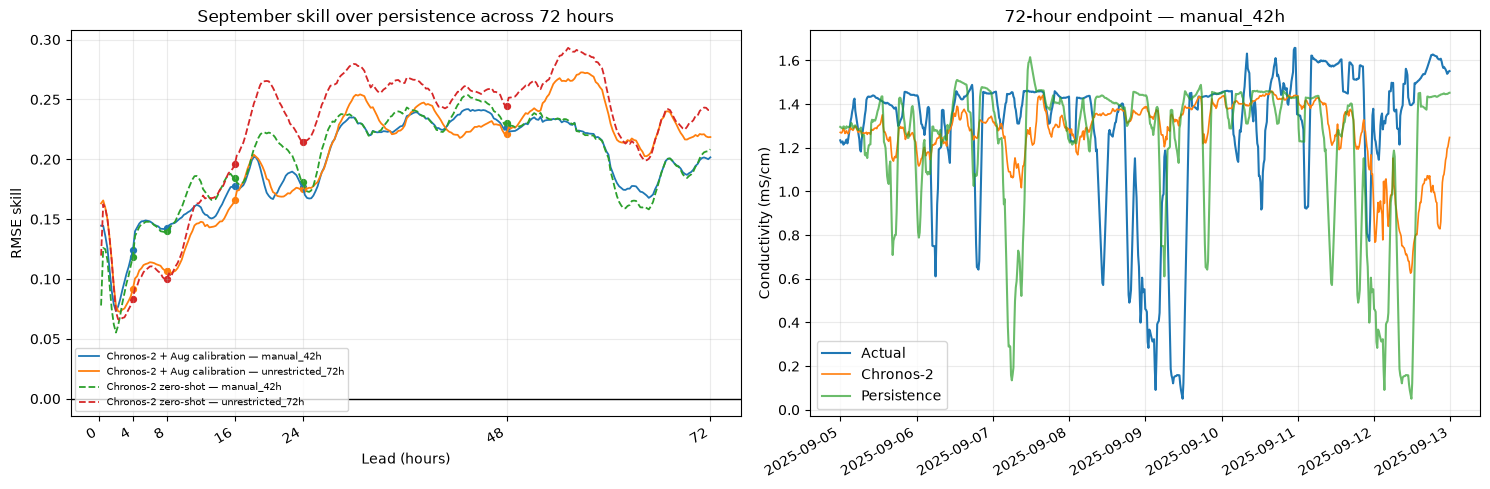

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for (model_name, representation), group in horizon_results.groupby(["Model", "Representation"]):
    linestyle = "-" if "calibration" in model_name else "--"
    axes[0].plot(
        group["Lead hours"], group["RMSE skill"],
        linewidth=1.3, linestyle=linestyle, label=f"{model_name} — {representation}",
    )
    marked = group[group["Lead hours"].isin(EVALUATION_HOURS)]
    axes[0].scatter(marked["Lead hours"], marked["RMSE skill"], s=18)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set(title=f"September skill over persistence across {FORECAST_HOURS} hours", xlabel="Lead (hours)", ylabel="RMSE skill")
axes[0].set_xticks([0, *EVALUATION_HOURS, FORECAST_HOURS])
axes[0].grid(alpha=.25)
axes[0].legend(fontsize=7)

# Select the visual representation using August calibration performance only.
validation_choice = pd.DataFrame(calibration_rows).sort_values("Validation RMSE").iloc[0]
best_representation = validation_choice["Representation"]
week = endpoint_predictions[("Chronos-2 + Aug calibration", best_representation)].loc["2025-09-05":"2025-09-12"]
axes[1].plot(week.index, week["Actual"], label="Actual", linewidth=1.5)
axes[1].plot(week.index, week["Prediction"], label="Chronos-2", linewidth=1.2)
axes[1].plot(week.index, week["Persistence"], label="Persistence", alpha=.7)
axes[1].set(title=f"{FORECAST_HOURS}-hour endpoint — {best_representation}", ylabel="Conductivity (mS/cm)")
axes[1].grid(alpha=.25)
axes[1].legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 5. Reproducible conclusion

In [8]:
for representation in datasets:
    row = results[
        (results["Model"] == "Chronos-2 + Aug calibration")
        & (results["Representation"] == representation)
        & (results["Scope"] == "all horizons")
    ].iloc[0]
    raw = results[
        (results["Model"] == "Chronos-2 zero-shot")
        & (results["Representation"] == representation)
        & (results["Scope"] == "all horizons")
    ].iloc[0]
    checkpoint_rows = results[
        (results["Model"] == "Chronos-2 + Aug calibration")
        & (results["Representation"] == representation)
        & (results["Scope"].isin(checkpoint_scopes))
    ].set_index("Scope")
    checkpoint_text = ", ".join(
        f"{hours} h={checkpoint_rows.loc[f'{hours}-hour mark', 'RMSE skill']:.3f}"
        for hours in EVALUATION_HOURS
    )
    print(
        f"{representation}: raw zero-shot RMSE={raw['RMSE']:.5f} "
        f"(skill {raw['RMSE skill']:.3f}); calibrated RMSE={row['RMSE']:.5f} "
        f"(overall {FORECAST_HOURS}-hour skill {row['RMSE skill']:.3f}); "
        f"calibrated checkpoint skill: {checkpoint_text}."
    )

best = results[
    (results["Model"] == "Chronos-2 + Aug calibration")
    & (results["Scope"] == "all horizons")
].sort_values("RMSE").iloc[0]
print(
    f"\nBest Chronos-2 representation: {best['Representation']} "
    f"with RMSE={best['RMSE']:.5f} and skill={best['RMSE skill']:.3f}."
)

unrestricted_72h: raw zero-shot RMSE=0.25945 (skill 0.229); calibrated RMSE=0.26725 (overall 72-hour skill 0.206); calibrated checkpoint skill: 4 h=0.092, 8 h=0.107, 16 h=0.166, 24 h=0.176, 48 h=0.221.
manual_42h: raw zero-shot RMSE=0.26782 (skill 0.204); calibrated RMSE=0.26952 (overall 72-hour skill 0.199); calibrated checkpoint skill: 4 h=0.124, 8 h=0.142, 16 h=0.178, 24 h=0.177, 48 h=0.227.

Best Chronos-2 representation: unrestricted_72h with RMSE=0.26725 and skill=0.206.
